# Анализа ChatTTS система за синтезу говора

Анализа обухвата синтезу говора помоћу ChatTTS система и испитивање утицаја дужине, стила и језичког садржаја текста на генерисани аудио-сигнал. Ефикасност система процењује се временом синтезе и real-time factor вредношћу, док се квалитет разматра на основу сигналних карактеристика и субјективних оцена.

## Припрема окружења

Учитане су библиотеке и помоћне функције за покретање ChatTTS модела, чување генерисаног говора, анализу аудио-сигнала и приказ резултата. Фиксна seed вредност користи се ради поновљивости стохастичког поступка синтезе.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT / "2-audio-tts" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT / "2-audio-tts"
sys.path.append(str(PROJECT_ROOT / "src"))

from tts_experiments import (
    FIGURES_DIR,
    build_results_table,
    ensure_directories,
    environment_report,
    load_chattts,
    merge_subjective_scores,
    plot_waveform_and_mel,
    read_subjective_scores,
    read_text_manifest,
    save_table,
    set_seed,
    synthesize_manifest,
)

set_seed(42)
ensure_directories()
plt.rcParams["figure.figsize"] = (9, 5)

## Конфигурација софтвера и хардвера

Забележене су верзије Python окружења, PyTorch и ChatTTS библиотека, као и подаци о доступном хардверу. Конфигурација окружења директно утиче на брзину генерисања говора и могућност коришћења хардверског убрзања.

In [2]:
env = environment_report()
env_table = pd.DataFrame([env]).T.rename(columns={0: "value"})
env_table

,value
python,3.13.3
python_executable,/Users/nemanjastojanovic/Desktop/elfak/2-audio...
platform,macOS-15.7.3-arm64-arm-64bit-Mach-O
processor,arm
torch,2.8.0
cuda_available,False
cuda_device,None
ChatTTS,installed
torchaudio,2.8.0
librosa,0.11.0


In [3]:
env_table.to_csv(PROJECT_ROOT / "results" / "tables" / "environment.csv")

## Текстуални скуп и категорије примера

Текстуални скуп садржи кратке реченице, дуже пасусе, дијалог, питања, узвике, бројеве и скраћенице. Укључени су српски, енглески и мешовити примери како би се испитало понашање модела при различитој структури и језичком садржају улаза.

In [4]:
manifest = read_text_manifest(PROJECT_ROOT / "data" / "text_manifest.csv")
save_table(manifest, "text_manifest_with_counts.csv")
manifest

,text_id,language,category,style,text,char_count,word_count,has_numbers,has_special_tokens
0,short_neutral,en,length,neutral,Chat T T S is a conversational text to speech ...,82,14,False,False
1,medium_paragraph,en,length,neutral,This example is longer than the first sentence...,228,38,False,False
2,long_paragraph,en,length,neutral,Conversational speech synthesis is important f...,465,62,False,False
3,question,en,style,question,Can a synthetic voice sound natural when it as...,66,12,False,False
4,exclamation,en,style,exclamation,This result is surprisingly expressive and eas...,62,9,False,False
5,dialogue_reply,en,style,dialogue,I understand your request. Let me explain the ...,100,18,False,False
6,numbers_terms,en,content,technical,The model generated 24 kilohertz audio in 3.5 ...,107,25,True,False
7,abbreviations,en,content,technical,"NASA, CPU, GPU, and API are common abbreviatio...",100,16,False,False
8,serbian_short,sr,language,neutral,Ovo je kratak primer teksta na srpskom jeziku ...,82,13,False,False
9,mixed_language,mixed,language,dialogue,Ovo je mixed language primer: Chat T T S gener...,115,20,False,False


## Синтеза говора моделом ChatTTS

ChatTTS модел генерише посебан аудио-сигнал за сваки текстуални пример. Током синтезе мере се време обраде и трајање добијеног сигнала, а сваки резултат се чува као WAV датотека са фреквенцијом одмеравања од 24 kHz.

In [5]:
RUN_SYNTHESIS = True

if RUN_SYNTHESIS:
    chat = load_chattts(compile_model=False)
    synthesis_results = synthesize_manifest(chat, manifest, show_progress=False)
else:
    synthesis_results = []
    print("RUN_SYNTHESIS je False; ukljuci ga kada zelis generisanje audija.")

## Аутоматске временске и акустичке метрике

За сваки генерисани пример израчунавају се време синтезе, трајање аудио-сигнала и real-time factor. Анализа сигнала обухвата RMS ниво, стопу пролаза кроз нулу, спектрални центроид и просечну основну фреквенцију.

In [6]:
results_table = build_results_table(synthesis_results, manifest)
if not results_table.empty:
    save_table(results_table, "tts_results.csv")
results_table

,text_id,language,category,style,text,output_path,synthesis_time_s,audio_duration_s,real_time_factor,sample_rate,char_count,word_count,has_numbers,has_special_tokens,rms_db,zcr_mean,spectral_centroid_mean,pitch_mean_hz
0,short_neutral,en,length,neutral,Chat T T S is a conversational text to speech ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,10.928950,4.680458,2.335017,24000,82,14,False,False,-28.338275,0.185531,3155.915892,159.233423
1,medium_paragraph,en,length,neutral,This example is longer than the first sentence...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,27.616503,13.270667,2.081019,24000,228,38,False,False,-20.891533,0.133527,2758.953522,150.058435
2,long_paragraph,en,length,neutral,Conversational speech synthesis is important f...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,50.229221,23.385833,2.147848,24000,465,62,False,False,-19.660364,0.122476,2297.400617,112.947869
3,question,en,style,question,Can a synthetic voice sound natural when it as...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,8.931070,3.560917,2.508082,24000,66,12,False,False,-27.728414,0.159168,2666.608701,106.551618
4,exclamation,en,style,exclamation,This result is surprisingly expressive and eas...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,6.239138,2.915000,2.140356,24000,62,9,False,False,-22.857118,0.112429,2276.102181,121.753051
5,dialogue_reply,en,style,dialogue,I understand your request. Let me explain the ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,13.144707,6.339500,2.073461,24000,100,18,False,False,-24.235941,0.150089,2980.581752,152.702732
6,numbers_terms,en,content,technical,The model generated 24 kilohertz audio in 3.5 ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,17.970048,7.380833,2.434691,24000,107,25,True,False,-27.298302,0.101197,2169.922593,101.745739
7,abbreviations,en,content,technical,"NASA, CPU, GPU, and API are common abbreviatio...",/Users/nemanjastojanovic/Desktop/elfak/2-audio...,14.117636,6.145333,2.297294,24000,100,16,False,False,-22.995379,0.160584,2908.058949,108.458356
8,serbian_short,sr,language,neutral,Ovo je kratak primer teksta na srpskom jeziku ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,13.156404,5.562708,2.365108,24000,82,13,False,False,-23.721638,0.044428,1148.522278,118.931389
9,mixed_language,mixed,language,dialogue,Ovo je mixed language primer: Chat T T S gener...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,17.425627,7.682375,2.268260,24000,115,20,False,False,-21.415352,0.160397,2808.608929,134.144016


## Субјективна процена квалитета

Субјективна процена обухвата природност, разумљивост и уочене грешке у изговору. Оцене добијене слушањем повезују се са аутоматским метрикама како би се упоредиле перцептивне особине говора и измерене карактеристике сигнала.

In [7]:
scores = read_subjective_scores(PROJECT_ROOT / "data" / "subjective_scores_template.csv")
full_results = merge_subjective_scores(results_table, scores)
normalization_actions = {
    "short_neutral": "nije potrebna",
    "medium_paragraph": "nije potrebna",
    "long_paragraph": "nije potrebna",
    "question": "nije potrebna",
    "exclamation": "nije potrebna",
    "dialogue_reply": "nije potrebna",
    "numbers_terms": "brojeve i skracenice zapisati fonetski",
    "abbreviations": "skracenice razdvojiti ili zapisati fonetski",
    "serbian_short": "pozeljna provera i fonetska adaptacija srpskih reci",
    "mixed_language": "razdvojiti jezike i fonetski prilagoditi srpske reci",
}
normalization_ids = {"numbers_terms", "abbreviations", "serbian_short", "mixed_language"}
if not full_results.empty:
    full_results["manual_normalization_needed"] = full_results["text_id"].isin(normalization_ids)
    full_results["normalization_action"] = full_results["text_id"].map(normalization_actions)
if not full_results.empty:
    save_table(full_results, "tts_results_with_subjective_scores.csv")
full_results

,text_id,language,category,style,text,output_path,synthesis_time_s,audio_duration_s,real_time_factor,sample_rate,...,rms_db,zcr_mean,spectral_centroid_mean,pitch_mean_hz,naturalness_1_5,intelligibility_1_5,pronunciation_errors,notes,manual_normalization_needed,normalization_action
0,short_neutral,en,length,neutral,Chat T T S is a conversational text to speech ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,10.928950,4.680458,2.335017,24000,...,-28.338275,0.185531,3155.915892,159.233423,5,5,0,I understand this short neutral sentence perfe...,False,nije potrebna
1,medium_paragraph,en,length,neutral,This example is longer than the first sentence...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,27.616503,13.270667,2.081019,24000,...,-20.891533,0.133527,2758.953522,150.058435,5,5,0,I understand this medium paragraph perfectly,False,nije potrebna
2,long_paragraph,en,length,neutral,Conversational speech synthesis is important f...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,50.229221,23.385833,2.147848,24000,...,-19.660364,0.122476,2297.400617,112.947869,4,5,0,"I understand this long paragraph perfectly, bu...",False,nije potrebna
3,question,en,style,question,Can a synthetic voice sound natural when it as...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,8.931070,3.560917,2.508082,24000,...,-27.728414,0.159168,2666.608701,106.551618,4,5,0,I understand this question very good,False,nije potrebna
4,exclamation,en,style,exclamation,This result is surprisingly expressive and eas...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,6.239138,2.915000,2.140356,24000,...,-22.857118,0.112429,2276.102181,121.753051,5,5,0,I understand this exclamation very good,False,nije potrebna
5,dialogue_reply,en,style,dialogue,I understand your request. Let me explain the ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,13.144707,6.339500,2.073461,24000,...,-24.235941,0.150089,2980.581752,152.702732,5,5,0,I understand this dialogue reply very good,False,nije potrebna
6,numbers_terms,en,content,technical,The model generated 24 kilohertz audio in 3.5 ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,17.970048,7.380833,2.434691,24000,...,-27.298302,0.101197,2169.922593,101.745739,5,5,0,I understand this numbers and terms very good,True,brojeve i skracenice zapisati fonetski
7,abbreviations,en,content,technical,"NASA, CPU, GPU, and API are common abbreviatio...",/Users/nemanjastojanovic/Desktop/elfak/2-audio...,14.117636,6.145333,2.297294,24000,...,-22.995379,0.160584,2908.058949,108.458356,5,5,0,I understand this abbreviations very good,True,skracenice razdvojiti ili zapisati fonetski
8,serbian_short,sr,language,neutral,Ovo je kratak primer teksta na srpskom jeziku ...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,13.156404,5.562708,2.365108,24000,...,-23.721638,0.044428,1148.522278,118.931389,3,2,4,Serbian words unstable,True,pozeljna provera i fonetska adaptacija srpskih...
9,mixed_language,mixed,language,dialogue,Ovo je mixed language primer: Chat T T S gener...,/Users/nemanjastojanovic/Desktop/elfak/2-audio...,17.425627,7.682375,2.268260,24000,...,-21.415352,0.160397,2808.608929,134.144016,3,2,4,Mixed language words unstable,True,razdvojiti jezike i fonetski prilagoditi srpsk...


### Поређење садржаја и ручна нормализација

Обичан неутрални текст користи се као референтни пример за поређење са текстом који садржи бројеве, техничке термине и скраћенице. Додатно је евидентирано да ли је пре синтезе потребна ручна нормализација и која измена текста је примењива.

In [8]:
content_ids = ["short_neutral", "numbers_terms", "abbreviations"]
content_labels = {
    "short_neutral": "obican tekst",
    "numbers_terms": "brojevi i tehnicki termini",
    "abbreviations": "skracenice",
}

content_comparison = full_results[full_results["text_id"].isin(content_ids)].copy()
if not content_comparison.empty:
    content_comparison["content_type"] = content_comparison["text_id"].map(content_labels)
    content_comparison = content_comparison[
        [
            "text_id",
            "content_type",
            "char_count",
            "synthesis_time_s",
            "real_time_factor",
            "naturalness_1_5",
            "intelligibility_1_5",
            "pronunciation_errors",
            "manual_normalization_needed",
            "normalization_action",
        ]
    ]
    save_table(content_comparison, "content_normalization_comparison.csv")
content_comparison


,text_id,content_type,char_count,synthesis_time_s,real_time_factor,naturalness_1_5,intelligibility_1_5,pronunciation_errors,manual_normalization_needed,normalization_action
0,short_neutral,obican tekst,82,10.928950,2.335017,5,5,0,False,nije potrebna
6,numbers_terms,brojevi i tehnicki termini,107,17.970048,2.434691,5,5,0,True,brojeve i skracenice zapisati fonetski
7,abbreviations,skracenice,100,14.117636,2.297294,5,5,0,True,skracenice razdvojiti ili zapisati fonetski


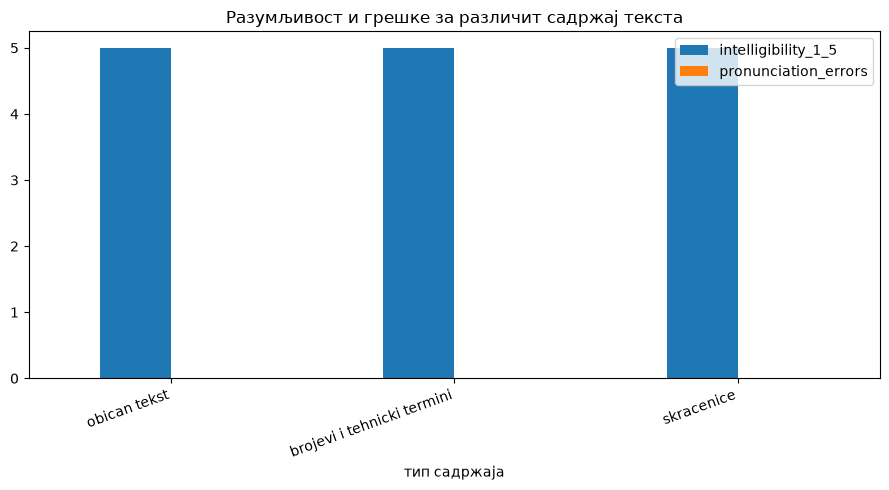

In [9]:
if not content_comparison.empty:
    ax = content_comparison.plot.bar(
        x="content_type",
        y=["intelligibility_1_5", "pronunciation_errors"],
    )
    ax.set_title("Разумљивост и грешке за различит садржај текста")
    ax.set_xlabel("тип садржаја")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "results" / "figures" / "content_quality_comparison.png", dpi=160)
    plt.show()


## Време синтезе и real-time factor

Зависност времена синтезе од броја карактера приказује утицај дужине улазног текста на рачунски трошак. Real-time factor представља однос времена потребног за генерисање и трајања добијеног аудио-сигнала, па вредности мање од један означавају синтезу бржу од реалног времена.

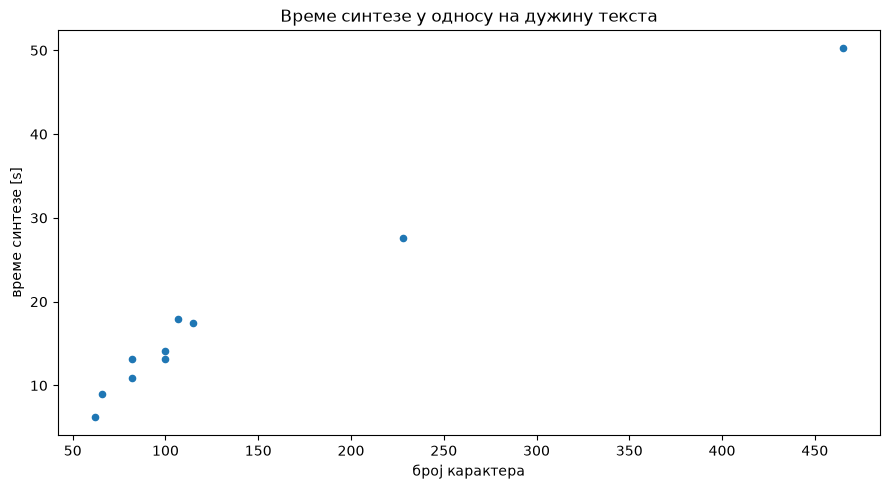

In [10]:
if not full_results.empty:
    ax = full_results.plot.scatter(x="char_count", y="synthesis_time_s")
    ax.set_title("Време синтезе у односу на дужину текста")
    ax.set_xlabel("број карактера")
    ax.set_ylabel("време синтезе [s]")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "results" / "figures" / "synthesis_time_by_length.png", dpi=160)
    plt.show()

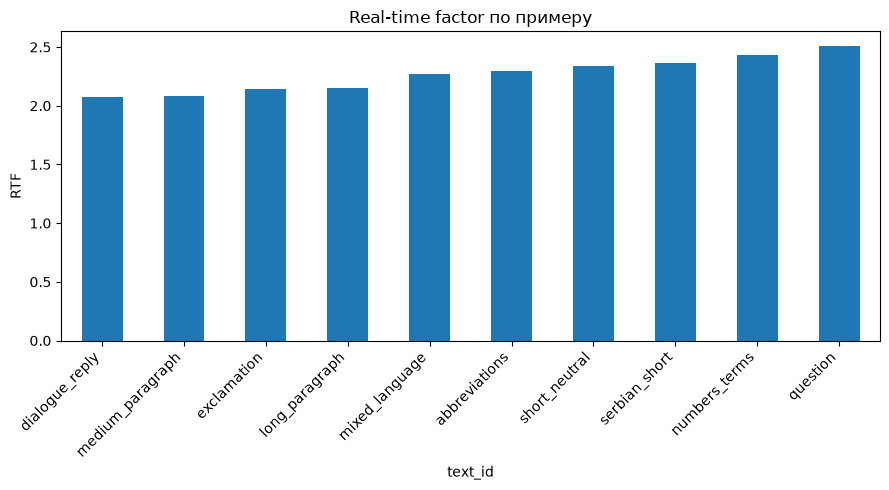

In [11]:
if not full_results.empty:
    ax = full_results.sort_values("real_time_factor").plot.bar(x="text_id", y="real_time_factor", legend=False)
    ax.set_title("Real-time factor по примеру")
    ax.set_xlabel("text_id")
    ax.set_ylabel("RTF")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "results" / "figures" / "rtf_by_text.png", dpi=160)
    plt.show()

## Таласни облик и mel спектрограм

Таласни облик приказује промену амплитуде током времена, док mel спектрограм описује расподелу енергије по перцептивно прилагођеној фреквенцијској скали. Ови прикази омогућавају анализу трајања, пауза, динамике и спектралне структуре генерисаног говора.

In [12]:
if not full_results.empty:
    for text_id in full_results["text_id"].head(2):
        row = full_results[full_results["text_id"] == text_id].iloc[0]
        plot_waveform_and_mel(row.output_path, FIGURES_DIR / f"{text_id}_waveform_mel.png")
    print("Sacuvane su waveform/mel slike za prva dva primera.")

Sacuvane su waveform/mel slike za prva dva primera.


## Утицај дужине, стила и садржаја текста

Анализа се заснива на поређењу три групе фактора: дужине текста, стила реченице и језичког садржаја. За сваку категорију пореде се време синтезе, RTF, висина гласа, енергија сигнала, субјективне оцене и потреба за ручном нормализацијом текста.

In [13]:
if not full_results.empty:
    contribution_summary = full_results.groupby(["category", "style"], as_index=False).agg(
        examples=("text_id", "count"),
        mean_chars=("char_count", "mean"),
        mean_synthesis_time_s=("synthesis_time_s", "mean"),
        mean_audio_duration_s=("audio_duration_s", "mean"),
        mean_rtf=("real_time_factor", "mean"),
        mean_pitch_hz=("pitch_mean_hz", "mean"),
        mean_rms_db=("rms_db", "mean"),
        mean_naturalness=("naturalness_1_5", "mean"),
        mean_intelligibility=("intelligibility_1_5", "mean"),
        total_pronunciation_errors=("pronunciation_errors", "sum"),
        manual_normalization_examples=("manual_normalization_needed", "sum"),
    )
    save_table(contribution_summary, "contribution_summary.csv")
else:
    contribution_summary = pd.DataFrame()

contribution_summary

,category,style,examples,mean_chars,mean_synthesis_time_s,mean_audio_duration_s,mean_rtf,mean_pitch_hz,mean_rms_db,mean_naturalness,mean_intelligibility,total_pronunciation_errors,manual_normalization_examples
0,content,technical,2,103.500000,16.043842,6.763083,2.365992,105.102047,-25.146840,5.000000,5.0,0,2
1,language,dialogue,1,115.000000,17.425627,7.682375,2.268260,134.144016,-21.415352,3.000000,2.0,4,1
2,language,neutral,1,82.000000,13.156404,5.562708,2.365108,118.931389,-23.721638,3.000000,2.0,4,1
3,length,neutral,3,258.333333,29.591558,13.778986,2.187961,140.746576,-22.963391,4.666667,5.0,0,0
4,style,dialogue,1,100.000000,13.144707,6.339500,2.073461,152.702732,-24.235941,5.000000,5.0,0,0
5,style,exclamation,1,62.000000,6.239138,2.915000,2.140356,121.753051,-22.857118,5.000000,5.0,0,0
6,style,question,1,66.000000,8.931070,3.560917,2.508082,106.551618,-27.728414,4.000000,5.0,0,0


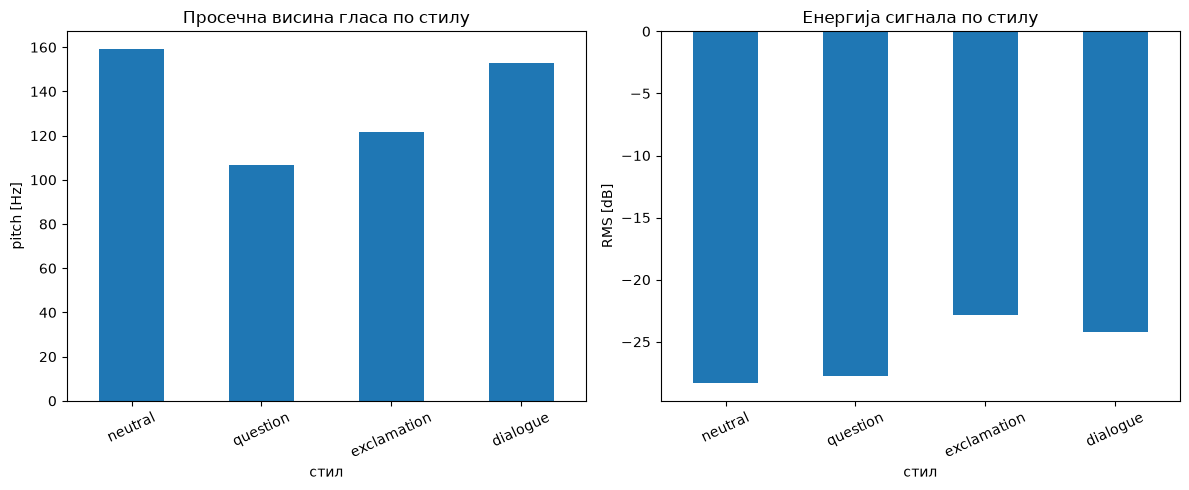

In [14]:
if not full_results.empty:
    style_ids = ["short_neutral", "question", "exclamation", "dialogue_reply"]
    style_labels = {
        "short_neutral": "neutral",
        "question": "question",
        "exclamation": "exclamation",
        "dialogue_reply": "dialogue",
    }
    style_table = full_results[full_results["text_id"].isin(style_ids)].copy()
    if not style_table.empty:
        style_table["comparison_style"] = style_table["text_id"].map(style_labels)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        style_table.plot.bar(
            x="comparison_style", y="pitch_mean_hz", legend=False, ax=axes[0]
        )
        axes[0].set_title("Просечна висина гласа по стилу")
        axes[0].set_xlabel("стил")
        axes[0].set_ylabel("pitch [Hz]")
        style_table.plot.bar(
            x="comparison_style", y="rms_db", legend=False, ax=axes[1]
        )
        axes[1].set_title("Енергија сигнала по стилу")
        axes[1].set_xlabel("стил")
        axes[1].set_ylabel("RMS [dB]")
        for axis in axes:
            axis.tick_params(axis="x", rotation=25)
        plt.tight_layout()
        plt.savefig(PROJECT_ROOT / "results" / "figures" / "style_pitch_energy.png", dpi=160)
        plt.show()
        save_table(
            style_table[
                [
                    "text_id",
                    "comparison_style",
                    "pitch_mean_hz",
                    "rms_db",
                    "naturalness_1_5",
                    "intelligibility_1_5",
                    "pronunciation_errors",
                ]
            ],
            "style_comparison_with_neutral.csv",
        )

## Закључак

Време синтезе расло је са дужином текста, а све измерене RTF вредности биле су веће од један, што показује да је генерисање на коришћеном CPU окружењу било спорије од реалног времена. Енглески примери добили су високе оцене природности и разумљивости, док су српски и мешовити текст показали нестабилнији изговор и више грешака. 

Резултати указују да ChatTTS успешно обрађује различите енглеске стилове и садржаје, али има ограничења при синтези српског говора.